# Personal Consumption Expenditures — m/m & y/y Changes and Contributions
### BEA NIPA Table 2.8.5 (PCE by Major Type of Product, Monthly)

This notebook pulls **BEA NIPA Table 2.8.5** via the BEA Data API, computes
**month-over-month (m/m)** and **year-over-year (y/y)** percent changes, and decomposes those
changes into **contributions** that drill down the spending hierarchy:

```
PCE
├─ Goods
│  ├─ Durable goods      → motor vehicles, furnishings, recreational, other
│  └─ Nondurable goods   → food & beverages, clothing, gasoline, other
└─ Services
   ├─ Household services → housing & utilities, health care, transportation,
   │                       recreation, food services, financial, other
   └─ NPISH final consumption
```

**Methodology.** Table 2.8.5 is in *current dollars* (nominal, seasonally adjusted at annual
rates, millions of dollars), so the aggregates are exact sums of their components and
contributions are **additive**. For any line *i*, with total PCE as the denominator:

- m/m % change:  $\;mm_i = (X_{i,t}/X_{i,t-1}-1)\times 100$
- y/y % change:  $\;yy_i = (X_{i,t}/X_{i,t-12}-1)\times 100$
- **m/m contribution (pp):**  $\;c^{mm}_i = (X_{i,t}-X_{i,t-1})/\text{PCE}_{t-1}\times 100$
- **y/y contribution (pp):**  $\;c^{yy}_i = (X_{i,t}-X_{i,t-12})/\text{PCE}_{t-12}\times 100$

Each contribution equals **weight × own growth**, where the weight is the line's prior-period
share of total PCE. Because the denominator is total PCE everywhere, the contributions *nest*:
durable + nondurable contributions sum to the Goods contribution, the lowest-level items sum to
total PCE growth, etc.

*Data source:* U.S. Bureau of Economic Analysis, NIPA Table 2.8.5, via the
[BEA Data API](https://apps.bea.gov/api/). Values are current-dollar, SAAR, millions.

## 0. Imports & configuration

In [1]:
import os
import json
import datetime
import urllib.request
import urllib.parse
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- BEA API key: prefer env var / local file, fall back to the provided key ---
def get_api_key():
    key = os.environ.get("BEA_API_KEY")
    if key:
        return key.strip()
    for fn in ("bea_api_key.txt", "API key.txt", "API Keys.txt"):
        p = Path(fn)
        if p.exists():
            return p.read_text().strip()
    return "FD4E7F46-5D89-4CA8-BE48-4F5997F83B3B"  # fallback (move to env/file for security)

BEA_API_KEY    = get_api_key()
TABLE          = "T20805"                       # NIPA Table 2.8.5
FREQ           = "M"                            # monthly
START_YEAR     = 2014                           # pull enough history for y/y + trend
END_YEAR       = datetime.date.today().year
N_TREND_MONTHS = 12                             # window for the trend view

OUTDIR = Path("outputs")
OUTDIR.mkdir(exist_ok=True)

## 1. Fetch data from the BEA API

In [2]:
def fetch_bea_nipa(table, freq, years, api_key=BEA_API_KEY):
    """Return the list of observation records for a NIPA table from the BEA API."""
    params = {
        "UserID": api_key,
        "method": "GetData",
        "datasetname": "NIPA",
        "TableName": table,
        "Frequency": freq,
        "Year": ",".join(str(y) for y in years),
        "ResultFormat": "json",
    }
    url = "https://apps.bea.gov/api/data/?" + urllib.parse.urlencode(params)
    with urllib.request.urlopen(url, timeout=60) as resp:
        payload = json.loads(resp.read().decode("utf-8"))
    bea = payload.get("BEAAPI", {})
    if bea.get("Error"):
        raise RuntimeError(f"BEA API error: {bea['Error']}")
    results = bea.get("Results")
    if isinstance(results, list):
        results = results[0]
    if not results or results.get("Error"):
        raise RuntimeError(f"BEA API error: {results.get('Error') if results else 'no results'}")
    return results["Data"]


years   = list(range(START_YEAR, END_YEAR + 1))
records = fetch_bea_nipa(TABLE, FREQ, years)
print(f"Fetched {len(records):,} observations for years {years[0]}-{years[-1]}.")

Fetched 4,588 observations for years 2014-2026.


## 2. Parse into tidy (`raw`), metadata (`meta`) and wide (`levels`) tables

In [3]:
def parse_time_period(tp):
    """'2026M04' -> Timestamp('2026-04-01')."""
    y, m = tp.split("M")
    return pd.Timestamp(int(y), int(m), 1)


raw = pd.DataFrame(records)
raw["value"] = pd.to_numeric(
    raw["DataValue"].astype(str).str.replace(",", "", regex=False), errors="coerce")
raw["LineNumber"] = pd.to_numeric(raw["LineNumber"], errors="coerce").astype("Int64")
raw["date"] = raw["TimePeriod"].map(parse_time_period)

# line metadata (one row per series)
meta = (raw[["LineNumber", "SeriesCode", "LineDescription"]]
        .drop_duplicates().sort_values("LineNumber").reset_index(drop=True))
DESC = meta.set_index("SeriesCode")["LineDescription"].to_dict()

# wide table of current-dollar levels: rows = month, cols = series
levels = (raw.pivot_table(index="date", columns="SeriesCode", values="value", aggfunc="first")
          .sort_index())

print(f"Levels: {levels.shape[1]} series x {levels.shape[0]} months "
      f"({levels.index.min():%Y-%m} to {levels.index.max():%Y-%m})")
meta

Levels: 31 series x 148 months (2014-01 to 2026-04)


,LineNumber,SeriesCode,LineDescription
0,1,DPCERC,Personal consumption expenditures (PCE)
1,2,DGDSRC,Goods
2,3,DDURRC,Durable goods
3,4,DMOTRC,Motor vehicles and parts
4,5,DFDHRC,Furnishings and durable household equipment
5,6,DREQRC,Recreational goods and vehicles
6,7,DODGRC,Other durable goods
7,8,DNDGRC,Nondurable goods
8,9,DFXARC,Food and beverages purchased for off-premises ...
9,10,DCLORC,Clothing and footwear


## 3. Define the Table 2.8.5 additive hierarchy

`HIERARCHY` lists each line as `(SeriesCode, parent SeriesCode, depth)`. Lines 1–22 form the
additive tree (lines 25–31 of the table are memo/addenda and are intentionally excluded). The
**leaf** nodes (lowest level of each branch) sum exactly to total PCE.

In [4]:
# (SeriesCode, parent SeriesCode, depth)
HIERARCHY = [
    ("DPCERC", None,     0),  # Personal consumption expenditures (PCE)
    ("DGDSRC", "DPCERC", 1),  #   Goods
    ("DDURRC", "DGDSRC", 2),  #     Durable goods
    ("DMOTRC", "DDURRC", 3),  #       Motor vehicles and parts
    ("DFDHRC", "DDURRC", 3),  #       Furnishings & durable household equipment
    ("DREQRC", "DDURRC", 3),  #       Recreational goods and vehicles
    ("DODGRC", "DDURRC", 3),  #       Other durable goods
    ("DNDGRC", "DGDSRC", 2),  #     Nondurable goods
    ("DFXARC", "DNDGRC", 3),  #       Food & beverages purchased off-premises
    ("DCLORC", "DNDGRC", 3),  #       Clothing and footwear
    ("DGOERC", "DNDGRC", 3),  #       Gasoline and other energy goods
    ("DONGRC", "DNDGRC", 3),  #       Other nondurable goods
    ("DSERRC", "DPCERC", 1),  #   Services
    ("DHCERC", "DSERRC", 2),  #     Household consumption expenditures (services)
    ("DHUTRC", "DHCERC", 3),  #       Housing and utilities
    ("DHLCRC", "DHCERC", 3),  #       Health care
    ("DTRSRC", "DHCERC", 3),  #       Transportation services
    ("DRCARC", "DHCERC", 3),  #       Recreation services
    ("DFSARC", "DHCERC", 3),  #       Food services and accommodations
    ("DIFSRC", "DHCERC", 3),  #       Financial services and insurance
    ("DOTSRC", "DHCERC", 3),  #       Other services
    ("DNPIRC", "DSERRC", 2),  #     Final consumption expenditures of NPISHs
]

PCE      = "DPCERC"
SERIES   = [s for s, _, _ in HIERARCHY]
DEPTH    = {s: d for s, _, d in HIERARCHY}
CHILDREN = {}
for s, p, _ in HIERARCHY:
    if p is not None:
        CHILDREN.setdefault(p, []).append(s)
LEAVES = [s for s in SERIES if s not in CHILDREN]   # lowest-level items; sum to PCE

missing = [s for s in SERIES if s not in levels.columns]
assert not missing, f"Series missing from API response: {missing}"
print(f"{len(SERIES)} series in hierarchy, {len(LEAVES)} leaves, {len(CHILDREN)} aggregates.")

22 series in hierarchy, 16 leaves, 6 aggregates.


## 4. Compute changes, contributions, weights — and verify additivity

In [5]:
# percent changes
mm = levels[SERIES].pct_change(1,  fill_method=None) * 100    # month-over-month %
yy = levels[SERIES].pct_change(12, fill_method=None) * 100    # year-over-year %

# contributions to TOTAL PCE growth (percentage points)
pce_lag1, pce_lag12 = levels[PCE].shift(1), levels[PCE].shift(12)
cmm = levels[SERIES].diff(1).div(pce_lag1,  axis=0) * 100     # m/m contribution (pp of PCE)
cyy = levels[SERIES].diff(12).div(pce_lag12, axis=0) * 100    # y/y contribution (pp of PCE)

# weight = current-month share of total PCE (%)
share = levels[SERIES].div(levels[PCE], axis=0) * 100

latest = levels.index.max()

# --- additivity checks (nominal table => contributions must reconcile exactly) ---
assert np.allclose(levels[LEAVES].sum(axis=1), levels[PCE], rtol=1e-4), \
    "leaf levels do not sum to PCE"
assert abs(cmm.loc[latest, LEAVES].sum() - mm.loc[latest, PCE]) < 0.02, \
    "m/m leaf contributions do not reconcile to PCE m/m %"
assert abs(cyy.loc[latest, LEAVES].sum() - yy.loc[latest, PCE]) < 0.02, \
    "y/y leaf contributions do not reconcile to PCE y/y %"
for parent, kids in CHILDREN.items():
    assert abs(cmm.loc[latest, kids].sum() - cmm.loc[latest, parent]) < 0.02, \
        f"{parent} children do not sum to parent"

print(f"Latest month: {latest:%B %Y}")
print(f"PCE  m/m = {mm.loc[latest, PCE]:+.3f}%   (sum of leaf contribs = {cmm.loc[latest, LEAVES].sum():+.3f} pp)")
print(f"PCE  y/y = {yy.loc[latest, PCE]:+.3f}%   (sum of leaf contribs = {cyy.loc[latest, LEAVES].sum():+.3f} pp)")
print("Additivity checks passed.")

Latest month: April 2026
PCE  m/m = +0.508%   (sum of leaf contribs = +0.508 pp)
PCE  y/y = +5.943%   (sum of leaf contribs = +5.943 pp)
Additivity checks passed.


## 5. Headline contribution table

The table below shows, for the selected month, each line's **weight** (share of PCE), its
**m/m** and **y/y** percent change, and its **contribution** to total PCE growth in percentage
points. Rows are indented by hierarchy level; child contributions sum to their parent and the
leaf contributions sum to total PCE.

Set `MONTH` to any month in the data to re-render (defaults to the latest available).

In [6]:
MONTH = latest        # e.g. pd.Timestamp(2025, 12, 1) for a specific month

def build_table(month):
    rows = []
    for s in SERIES:
        rows.append({
            "Category": "    " * DEPTH[s] + DESC.get(s, s),
            "SeriesCode": s,
            "Level": DEPTH[s],
            "Weight (% of PCE)": share.loc[month, s],
            "m/m %": mm.loc[month, s],
            "y/y %": yy.loc[month, s],
            "m/m contrib (pp)": cmm.loc[month, s],
            "y/y contrib (pp)": cyy.loc[month, s],
        })
    return pd.DataFrame(rows)

NUM_COLS = ["m/m %", "y/y %", "m/m contrib (pp)", "y/y contrib (pp)"]

def style_table(tdf, month):
    show = tdf.copy()
    show["Category"] = show["Category"].str.replace("    ", " " * 4, regex=False)
    depths = tdf["Level"].tolist()
    show = show[["Category", "Weight (% of PCE)"] + NUM_COLS]

    def bold_rows(row):
        d = depths[row.name]
        fw = "700" if d <= 1 else ("600" if d == 2 else "400")
        return [f"font-weight:{fw};"] * len(row)

    def color(series):
        out = []
        for v in series:
            if pd.isna(v):   out.append("color:#aaa;")
            elif v > 0:      out.append("color:#0a7d2c;")
            elif v < 0:      out.append("color:#c0392b;")
            else:            out.append("color:#888;")
        return out

    return (show.style
            .format({"Weight (% of PCE)": "{:.1f}", "m/m %": "{:+.2f}", "y/y %": "{:+.2f}",
                     "m/m contrib (pp)": "{:+.3f}", "y/y contrib (pp)": "{:+.3f}"}, na_rep="–")
            .apply(bold_rows, axis=1)
            .apply(color, subset=NUM_COLS)
            .hide(axis="index")
            .set_caption(f"PCE by Major Type of Product (Table 2.8.5) — contributions to total "
                         f"PCE growth, {month:%B %Y} (current $, SAAR)")
            .set_properties(subset=["Category"], **{"text-align": "left"})
            .set_table_styles([
                {"selector": "caption", "props": [("font-weight", "700"), ("font-size", "13px"),
                                                   ("padding", "6px"), ("caption-side", "top")]},
                {"selector": "th.col_heading", "props": [("text-align", "right")]},
                {"selector": "td", "props": [("text-align", "right"), ("padding", "2px 10px")]},
            ]))

style_table(build_table(MONTH), MONTH)

Category,Weight (% of PCE),m/m %,y/y %,m/m contrib (pp),y/y contrib (pp)
Personal consumption expenditures (PCE),100.0,+0.51,+5.94,+0.508,+5.943
Goods,31.2,+0.65,+5.63,+0.201,+1.761
Durable goods,10.8,+0.02,+3.30,+0.002,+0.366
Motor vehicles and parts,3.5,-1.17,-4.25,-0.042,-0.166
Furnishings and durable household equipment,2.4,+0.04,+4.07,+0.001,+0.099
Recreational goods and vehicles,3.4,+1.10,+10.03,+0.037,+0.330
Other durable goods,1.4,+0.41,+7.14,+0.006,+0.102
Nondurable goods,20.4,+0.98,+6.91,+0.199,+1.396
Food and beverages purchased for off-premises consumption,7.1,+0.61,+2.85,+0.043,+0.209
Clothing and footwear,2.7,-0.51,+7.31,-0.014,+0.194


## 6. Trend view — last 12 months

Stacked bars show the m/m contributions of **Durable goods + Nondurable goods + Services**
(which sum to total PCE), with the black line marking the total PCE m/m % change. The table
beneath gives the detailed monthly contributions (pp) for the major categories.

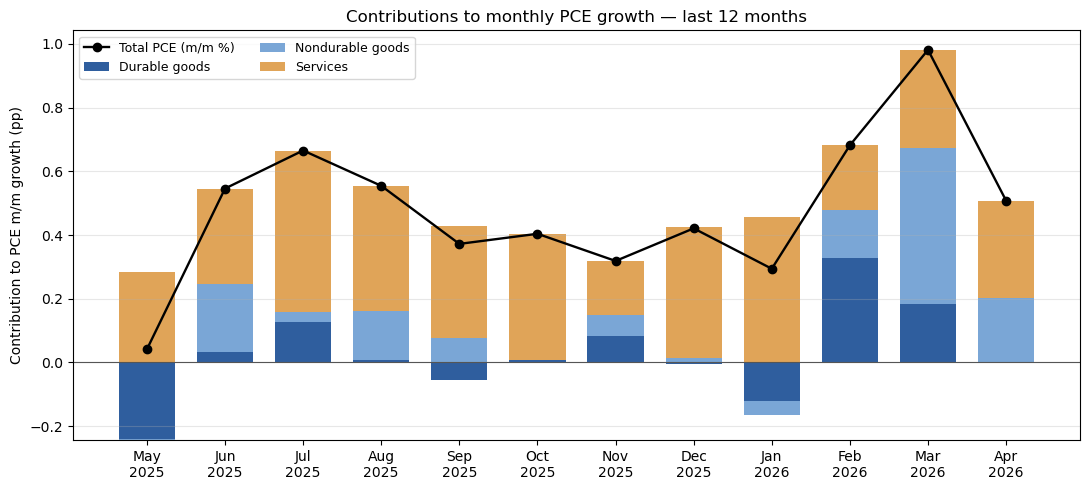

Monthly m/m contributions to PCE growth (percentage points):


,May 2025,Jun 2025,Jul 2025,Aug 2025,Sep 2025,Oct 2025,Nov 2025,Dec 2025,Jan 2026,Feb 2026,Mar 2026,Apr 2026
Personal consumption expenditures (PCE),0.041,0.546,0.666,0.555,0.372,0.404,0.319,0.421,0.294,0.682,0.982,0.508
Goods,-0.244,0.246,0.160,0.162,0.019,0.007,0.149,0.011,-0.164,0.479,0.675,0.201
Durable goods,-0.239,0.032,0.128,0.007,-0.056,0.007,0.082,-0.004,-0.120,0.327,0.183,0.002
Nondurable goods,-0.004,0.214,0.032,0.155,0.076,-0.001,0.067,0.015,-0.044,0.153,0.492,0.199
Services,0.285,0.300,0.506,0.393,0.353,0.397,0.169,0.411,0.458,0.203,0.307,0.307
Housing and utilities,0.057,0.095,0.033,0.028,0.062,0.075,0.042,0.123,0.078,0.017,0.036,0.104
Health care,0.087,0.124,0.141,0.148,0.099,0.058,0.084,0.070,0.085,-0.001,0.052,0.030
Transportation services,0.035,-0.008,0.011,0.055,0.033,0.028,-0.018,0.016,0.022,0.077,0.026,0.006
Recreation services,0.032,-0.004,0.030,0.041,-0.002,0.028,-0.000,0.097,0.012,-0.042,0.019,0.055
Food services and accommodations,0.014,0.038,0.009,0.038,0.016,-0.001,0.029,0.000,-0.024,0.043,0.014,0.052


In [7]:
recent = levels.index[-N_TREND_MONTHS:]

# --- stacked-bar chart (handles negative contributions correctly) ---
TREND_SERIES = ["DDURRC", "DNDGRC", "DSERRC"]   # durable, nondurable, services -> sum to PCE
colors = {"DDURRC": "#2f5e9e", "DNDGRC": "#7aa6d6", "DSERRC": "#e0a458"}

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(recent))
pos_bottom = np.zeros(len(recent))
neg_bottom = np.zeros(len(recent))
for s in TREND_SERIES:
    vals = cmm.loc[recent, s].to_numpy()
    pos, neg = np.clip(vals, 0, None), np.clip(vals, None, 0)
    ax.bar(x, pos, bottom=pos_bottom, color=colors[s], width=0.72, label=DESC[s])
    ax.bar(x, neg, bottom=neg_bottom, color=colors[s], width=0.72)
    pos_bottom += pos
    neg_bottom += neg

ax.plot(x, mm.loc[recent, PCE].to_numpy(), "o-", color="black", lw=1.7, label="Total PCE (m/m %)")
ax.axhline(0, color="#555", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([d.strftime("%b\n%Y") for d in recent])
ax.set_ylabel("Contribution to PCE m/m growth (pp)")
ax.set_title(f"Contributions to monthly PCE growth — last {N_TREND_MONTHS} months")
ax.legend(loc="upper left", fontsize=9, ncol=2)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

# --- detailed monthly contribution table (pp) ---
TREND_DETAIL = ["DPCERC", "DGDSRC", "DDURRC", "DNDGRC", "DSERRC",
                "DHUTRC", "DHLCRC", "DTRSRC", "DRCARC", "DFSARC", "DIFSRC", "DOTSRC", "DNPIRC"]
trend_tbl = cmm.loc[recent, TREND_DETAIL].T
trend_tbl.index = [("  " if DEPTH[s] >= 2 else "") + DESC[s] for s in TREND_DETAIL]
trend_tbl.columns = [d.strftime("%b %Y") for d in recent]
print("Monthly m/m contributions to PCE growth (percentage points):")
trend_tbl.round(3)

## 7. Export results

In [8]:
# full long-format history: level, %changes, contributions, weight for every line/month
def long_history():
    parts = {"level": levels[SERIES], "mm_pct": mm, "yy_pct": yy,
             "contrib_mm_pp": cmm, "contrib_yy_pp": cyy, "weight_pct_of_pce": share}
    frames = []
    for name, df in parts.items():
        f = df[SERIES].copy()
        f.index.name = "date"
        frames.append(f.reset_index().melt(id_vars="date", var_name="SeriesCode",
                                            value_name=name).set_index(["date", "SeriesCode"]))
    out = pd.concat(frames, axis=1).reset_index()
    out["LineNumber"]  = out["SeriesCode"].map(meta.set_index("SeriesCode")["LineNumber"])
    out["Description"] = out["SeriesCode"].map(DESC)
    cols = ["date", "LineNumber", "SeriesCode", "Description", "level",
            "mm_pct", "yy_pct", "contrib_mm_pp", "contrib_yy_pp", "weight_pct_of_pce"]
    return out.sort_values(["date", "LineNumber"]).reset_index(drop=True)[cols]

full = long_history()
full.to_csv(OUTDIR / "pce_2_8_5_full_history.csv", index=False)
build_table(latest).drop(columns="Level").to_csv(OUTDIR / "pce_2_8_5_latest_month_table.csv", index=False)
fig.savefig(OUTDIR / "pce_2_8_5_contributions_trend.png", dpi=150, bbox_inches="tight")

print("Wrote:")
for f in ("pce_2_8_5_full_history.csv", "pce_2_8_5_latest_month_table.csv",
          "pce_2_8_5_contributions_trend.png"):
    print(" ", (OUTDIR / f).resolve())

Wrote:
  C:\Users\abour\OneDrive\Economic Research\GDP\Personal Income and Spending\outputs\pce_2_8_5_full_history.csv
  C:\Users\abour\OneDrive\Economic Research\GDP\Personal Income and Spending\outputs\pce_2_8_5_latest_month_table.csv
  C:\Users\abour\OneDrive\Economic Research\GDP\Personal Income and Spending\outputs\pce_2_8_5_contributions_trend.png


## 8. Real (chained-dollar) analysis — Tables 2.8.6 & 2.8.2

Sections 1–7 use **current-dollar** PCE (Table 2.8.5), where components add up exactly. This
section repeats the analysis in **real / inflation-adjusted** terms:

- **Real % changes** (m/m, y/y) come from **Table 2.8.6** — Real PCE by Major Type of Product,
  Monthly, *Chained Dollars*.
- **Real m/m contributions** come straight from **Table 2.8.2** — BEA's *official* "Contributions
  to Percent Change in Real PCE." These use the exact Fisher formula, so they are additive (they
  sum to the real PCE m/m % change) with no residual needed — better than deriving them ourselves.

**Why we don't just difference chained levels.** Chained dollars are *not additive* — in the latest
month the 16 leaf categories overstate real PCE by ~0.8%, and Durable goods overstates its four
items by ~2% — and Table 2.8.6 publishes *no residual line*. BEA resolves this in Table 2.8.2 with
the Fisher contribution formula, which we use directly for m/m.

**Year-over-year contributions are not published monthly by BEA**, so we compute them with the
standard **Laspeyres** approximation: each line's *prior-year share of nominal PCE* (Table 2.8.5)
times its *real* 12-month growth (Table 2.8.6), aggregated bottom-up so children sum to parents,
with a small **chain residual** row reconciling to the official real PCE y/y % change.

$$ c^{\,mm}_i \;=\; \text{Table 2.8.2 (official Fisher)} \qquad\qquad
   c^{\,yy}_i \;=\; \underbrace{\tfrac{V_{i,\,t-12}}{V_{\text{PCE},\,t-12}}}_{\text{nominal weight (2.8.5)}}\;\times\;
   \underbrace{\big(\tfrac{Q_{i,t}}{Q_{i,\,t-12}}-1\big)}_{\text{real growth (2.8.6)}}\times 100 $$

*Data sources:* BEA NIPA Tables 2.8.6 (chained $, SAAR) and 2.8.2 (contributions, percentage
points); nominal weights from Table 2.8.5 (§1). Monthly percent changes are simple (not annualized).

In [9]:
# --- 8.1 Fetch real levels (Table 2.8.6) and official m/m contributions (Table 2.8.2) ---
RTABLE, CTABLE = "T20806", "T20802"

# real chained-dollar levels
rrecords = fetch_bea_nipa(RTABLE, FREQ, years)
rraw = pd.DataFrame(rrecords)
rraw["value"] = pd.to_numeric(rraw["DataValue"].astype(str).str.replace(",", "", regex=False),
                              errors="coerce")
rraw["date"]  = rraw["TimePeriod"].map(parse_time_period)
rlevels = (rraw.pivot_table(index="date", columns="SeriesCode", values="value", aggfunc="first")
           .sort_index())

# official Fisher contributions to the real PCE m/m % change (percentage points)
crecords = fetch_bea_nipa(CTABLE, FREQ, years)
craw = pd.DataFrame(crecords)
craw["value"] = pd.to_numeric(craw["DataValue"].astype(str).str.replace(",", "", regex=False),
                              errors="coerce")
craw["LineNumber"] = pd.to_numeric(craw["LineNumber"], errors="coerce").astype("Int64")
craw["date"] = craw["TimePeriod"].map(parse_time_period)
clevels = (craw.pivot_table(index="date", columns="SeriesCode", values="value", aggfunc="first")
           .sort_index())
C282_BY_LINE = (craw[["LineNumber", "SeriesCode"]].drop_duplicates()
                .set_index("LineNumber")["SeriesCode"].to_dict())

# real series codes mirror the nominal hierarchy, with a trailing 'X' instead of 'C'
RSERIES = [s[:-1] + "X" for s in SERIES]
assert not [c for c in RSERIES if c not in rlevels.columns], "real (2.8.6) series missing"

print(f"Fetched {len(rrecords):,} real (2.8.6) + {len(crecords):,} contribution (2.8.2) obs.")
print(f"Real levels:  {rlevels.shape[0]} months {rlevels.index.min():%Y-%m}..{rlevels.index.max():%Y-%m} (chained $, SAAR)")
print(f"Official m/m contributions: {clevels.index.min():%Y-%m}..{clevels.index.max():%Y-%m} (percentage points)")

Fetched 4,588 real (2.8.6) + 4,588 contribution (2.8.2) obs.
Real levels:  148 months 2014-01..2026-04 (chained $, SAAR)
Official m/m contributions: 2014-01..2026-04 (percentage points)


In [10]:
# --- 8.2 Real changes, official m/m contributions, computed y/y contributions ---
# Re-key real levels by the nominal SeriesCode so we can reuse DESC/DEPTH/CHILDREN/LEAVES.
rlev = rlevels[RSERIES].copy()
rlev.columns = SERIES
nlev = levels[SERIES].reindex(rlev.index)              # nominal levels, same dates

# Real percent changes (chained dollars) -- headline real PCE growth (simple m/m, 12m y/y)
rmm = rlev.pct_change(1,  fill_method=None) * 100       # real m/m %
ryy = rlev.pct_change(12, fill_method=None) * 100       # real y/y %

# Official m/m contributions (Table 2.8.2), re-keyed to the nominal SeriesCode by line number
line_of = meta.set_index("SeriesCode")["LineNumber"]
rcmm = pd.DataFrame(index=rlev.index, columns=SERIES, dtype=float)
for s in SERIES:
    rcmm[s] = clevels[C282_BY_LINE[int(line_of[s])]].reindex(rlev.index)

# y/y contributions: Laspeyres (prior-year nominal weight x real 12m growth), aggregated bottom-up
w_lag12   = nlev.shift(12).div(nlev[PCE].shift(12), axis=0)
rcyy_leaf = w_lag12 * rlev.pct_change(12, fill_method=None) * 100

def _leaf_desc(node):
    if node not in CHILDREN:
        return [node]
    out = []
    for k in CHILDREN[node]:
        out += _leaf_desc(k)
    return out
LEAFDESC = {s: _leaf_desc(s) for s in SERIES}

rcyy = pd.DataFrame(index=rlev.index, columns=SERIES, dtype=float)
for s in SERIES:
    rcyy[s] = rcyy_leaf[LEAFDESC[s]].sum(axis=1)

# residual rows: real PCE growth minus the summed component contributions
resid_mm = rmm[PCE] - rcmm[LEAVES].sum(axis=1)         # ~0 (BEA rounding); m/m is additive
resid_yy = ryy[PCE] - rcyy[LEAVES].sum(axis=1)         # chain (Fisher) residual

rlatest = rlev.index.max()

# --- checks ---
assert abs(rcmm.loc[rlatest, PCE] - rcmm.loc[rlatest, LEAVES].sum()) < 0.05, \
    "official m/m leaf contributions do not sum to PCE contribution"
for parent, kids in CHILDREN.items():                  # y/y nests exactly by construction
    assert abs(rcyy.loc[rlatest, kids].sum() - rcyy.loc[rlatest, parent]) < 1e-9

print(f"Latest month: {rlatest:%B %Y}  (real, chained dollars)")
print(f"Real PCE  m/m = {rmm.loc[rlatest, PCE]:+.3f}%   "
      f"official contribs: leaves sum {rcmm.loc[rlatest, LEAVES].sum():+.2f} pp "
      f"(residual {resid_mm.loc[rlatest]:+.3f} pp)")
print(f"Real PCE  y/y = {ryy.loc[rlatest, PCE]:+.3f}%   "
      f"Laspeyres contribs: leaves sum {rcyy.loc[rlatest, LEAVES].sum():+.2f} pp "
      f"(chain residual {resid_yy.loc[rlatest]:+.3f} pp)")
print("Checks passed (official m/m additive; y/y children sum to parents).")

Latest month: April 2026  (real, chained dollars)
Real PCE  m/m = +0.108%   official contribs: leaves sum +0.10 pp (residual +0.008 pp)
Real PCE  y/y = +2.099%   Laspeyres contribs: leaves sum +2.11 pp (chain residual -0.008 pp)
Checks passed (official m/m additive; y/y children sum to parents).


### 8.3 Real headline contribution table

For the selected month: each line's **nominal weight** (share of PCE), its **real** m/m and y/y
percent change, and its **contribution** to real PCE growth (pp). The **m/m** contributions are
BEA's official Fisher figures (Table 2.8.2); the **y/y** contributions are the computed Laspeyres
approximation. The bottom row reconciles the component total to the official real PCE % change
(m/m: rounding only; y/y: chain residual). Set `RMONTH` to view any month.

In [11]:
# --- 8.3 Real headline contribution table ---
RMONTH = rlatest        # set to e.g. pd.Timestamp(2025, 12, 1) to view another month
RNUM_COLS = ["real m/m %", "real y/y %", "m/m contrib (pp)", "y/y contrib (pp)"]

def build_rtable(month):
    rows = []
    for s in SERIES:
        rows.append({
            "Category": "    " * DEPTH[s] + DESC.get(s, s),
            "Level": DEPTH[s],
            "Weight (% of PCE)": share.loc[month, s],
            "real m/m %": rmm.loc[month, s],
            "real y/y %": ryy.loc[month, s],
            "m/m contrib (pp)": rcmm.loc[month, s],
            "y/y contrib (pp)": rcyy.loc[month, s],
        })
    rows.append({                                       # reconciling residual row
        "Category": "Chain residual / rounding",
        "Level": 1,
        "Weight (% of PCE)": np.nan,
        "real m/m %": np.nan, "real y/y %": np.nan,
        "m/m contrib (pp)": resid_mm.loc[month],
        "y/y contrib (pp)": resid_yy.loc[month],
    })
    return pd.DataFrame(rows)

def style_rtable(tdf, month):
    show = tdf.copy()
    show["Category"] = show["Category"].str.replace("    ", " " * 4, regex=False)
    depths = tdf["Level"].tolist()
    show = show[["Category", "Weight (% of PCE)"] + RNUM_COLS]

    def bold_rows(row):
        d = depths[row.name]
        fw = "700" if d <= 1 else ("600" if d == 2 else "400")
        return [f"font-weight:{fw};"] * len(row)

    def color(series):
        out = []
        for v in series:
            if pd.isna(v):   out.append("color:#aaa;")
            elif v > 0:      out.append("color:#0a7d2c;")
            elif v < 0:      out.append("color:#c0392b;")
            else:            out.append("color:#888;")
        return out

    return (show.style
            .format({"Weight (% of PCE)": "{:.1f}", "real m/m %": "{:+.2f}", "real y/y %": "{:+.2f}",
                     "m/m contrib (pp)": "{:+.2f}", "y/y contrib (pp)": "{:+.2f}"}, na_rep="–")
            .apply(bold_rows, axis=1)
            .apply(color, subset=RNUM_COLS)
            .hide(axis="index")
            .set_caption(f"Real PCE by Major Type of Product — contributions to real PCE growth, "
                         f"{month:%B %Y}  (m/m: official Table 2.8.2; y/y: Laspeyres)")
            .set_properties(subset=["Category"], **{"text-align": "left"})
            .set_table_styles([
                {"selector": "caption", "props": [("font-weight", "700"), ("font-size", "13px"),
                                                   ("padding", "6px"), ("caption-side", "top")]},
                {"selector": "th.col_heading", "props": [("text-align", "right")]},
                {"selector": "td", "props": [("text-align", "right"), ("padding", "2px 10px")]},
            ]))

style_rtable(build_rtable(RMONTH), RMONTH)

Category,Weight (% of PCE),real m/m %,real y/y %,m/m contrib (pp),y/y contrib (pp)
Personal consumption expenditures (PCE),100.0,+0.11,+2.10,+0.10,+2.11
Goods,31.2,-0.08,+1.20,-0.03,+0.38
Durable goods,10.8,-0.56,-0.06,-0.06,-0.00
Motor vehicles and parts,3.5,-1.08,-4.16,-0.04,-0.16
Furnishings and durable household equipment,2.4,+0.17,+0.37,+0.00,+0.01
Recreational goods and vehicles,3.4,-0.51,+3.54,-0.02,+0.12
Other durable goods,1.4,-0.59,+2.46,-0.01,+0.04
Nondurable goods,20.4,+0.17,+1.88,+0.03,+0.38
Food and beverages purchased for off-premises consumption,7.1,+0.12,+0.34,+0.01,+0.02
Clothing and footwear,2.7,-0.91,+3.40,-0.02,+0.09


### 8.4 Real trend view — last 12 months

Stacked bars show the **official** real m/m contributions of Durable goods, Nondurable goods, and
Services (Table 2.8.2), which sum to the real PCE m/m % change (black line).

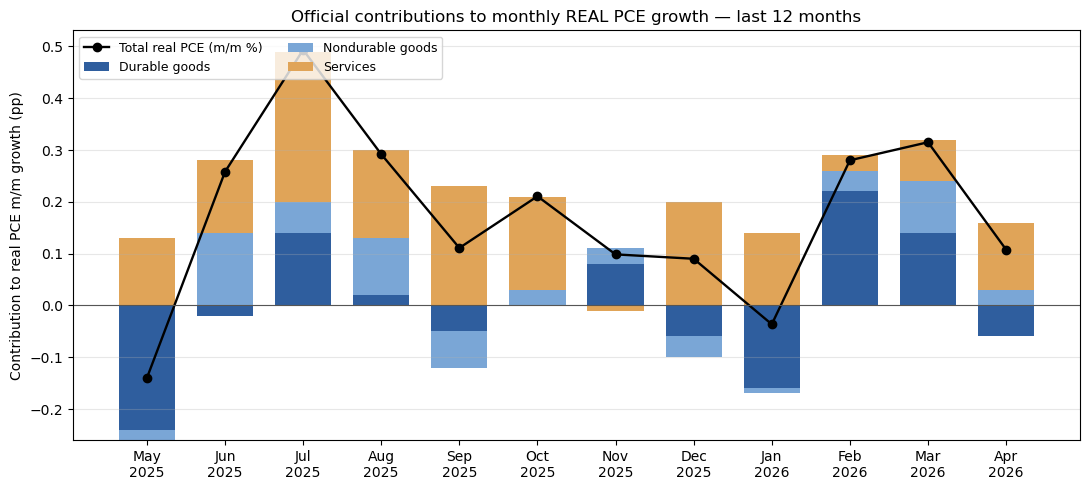

Monthly real m/m contributions to PCE growth (percentage points, official Table 2.8.2):


,May 2025,Jun 2025,Jul 2025,Aug 2025,Sep 2025,Oct 2025,Nov 2025,Dec 2025,Jan 2026,Feb 2026,Mar 2026,Apr 2026
Personal consumption expenditures (PCE),-0.10,0.30,0.50,0.30,0.10,0.20,0.10,0.10,0.00,0.30,0.30,0.10
Goods,-0.27,0.12,0.20,0.12,-0.12,0.03,0.11,-0.11,-0.18,0.25,0.23,-0.03
Durable goods,-0.24,-0.02,0.14,0.02,-0.05,0.00,0.08,-0.06,-0.16,0.22,0.14,-0.06
Nondurable goods,-0.02,0.14,0.06,0.11,-0.07,0.03,0.03,-0.04,-0.01,0.04,0.10,0.03
Services,0.13,0.14,0.29,0.17,0.23,0.18,-0.01,0.20,0.14,0.03,0.08,0.13
Housing and utilities,0.01,0.03,-0.01,-0.03,0.05,0.04,0.00,0.06,0.04,-0.02,-0.02,-0.01
Health care,0.07,0.05,0.10,0.12,0.08,-0.02,0.04,0.07,-0.01,-0.04,-0.01,0.02
Transportation services,0.03,-0.01,0.00,0.03,0.01,0.02,-0.03,0.02,0.00,0.05,-0.02,-0.01
Recreation services,0.03,0.00,0.02,0.05,-0.01,0.03,0.00,0.01,0.00,-0.02,0.01,0.04
Food services and accommodations,0.00,0.04,0.00,0.00,0.00,-0.01,0.02,-0.06,-0.03,0.02,0.00,0.01


In [12]:
# --- 8.4 Real m/m contribution trend (official, Table 2.8.2), last N months ---
fig_r, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(recent))
pos_bottom = np.zeros(len(recent))
neg_bottom = np.zeros(len(recent))
for s in TREND_SERIES:                                  # Durable, Nondurable, Services
    vals = rcmm.loc[recent, s].to_numpy()
    pos, neg = np.clip(vals, 0, None), np.clip(vals, None, 0)
    ax.bar(x, pos, bottom=pos_bottom, color=colors[s], width=0.72, label=DESC[s])
    ax.bar(x, neg, bottom=neg_bottom, color=colors[s], width=0.72)
    pos_bottom += pos
    neg_bottom += neg

ax.plot(x, rmm.loc[recent, PCE].to_numpy(), "o-", color="black", lw=1.7,
        label="Total real PCE (m/m %)")
ax.axhline(0, color="#555", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([d.strftime("%b\n%Y") for d in recent])
ax.set_ylabel("Contribution to real PCE m/m growth (pp)")
ax.set_title(f"Official contributions to monthly REAL PCE growth — last {N_TREND_MONTHS} months")
ax.legend(loc="upper left", fontsize=9, ncol=2)
ax.grid(axis="y", alpha=0.3)
fig_r.tight_layout()
plt.show()

# detailed monthly real contributions (pp), official Table 2.8.2
rtrend_tbl = rcmm.loc[recent, TREND_DETAIL].T
rtrend_tbl.index = [("  " if DEPTH[s] >= 2 else "") + DESC[s] for s in TREND_DETAIL]
rtrend_tbl.columns = [d.strftime("%b %Y") for d in recent]
print("Monthly real m/m contributions to PCE growth (percentage points, official Table 2.8.2):")
rtrend_tbl.round(2)

### 8.5 Momentum: monthly change vs 3-month annualized rate

For total real PCE, Services, and Goods: **bars** show the simple **m/m** real % change (left axis;
blue when positive, red when negative) and the **line** shows the **3-month annualized rate**
(3m % SAAR, right axis), computed as $(X_t/X_{t-3})^{4}-1$ from the chained-dollar levels. The SAAR
line smooths month-to-month noise to reveal underlying momentum. Window = last `N_DUAL_MONTHS`
months.

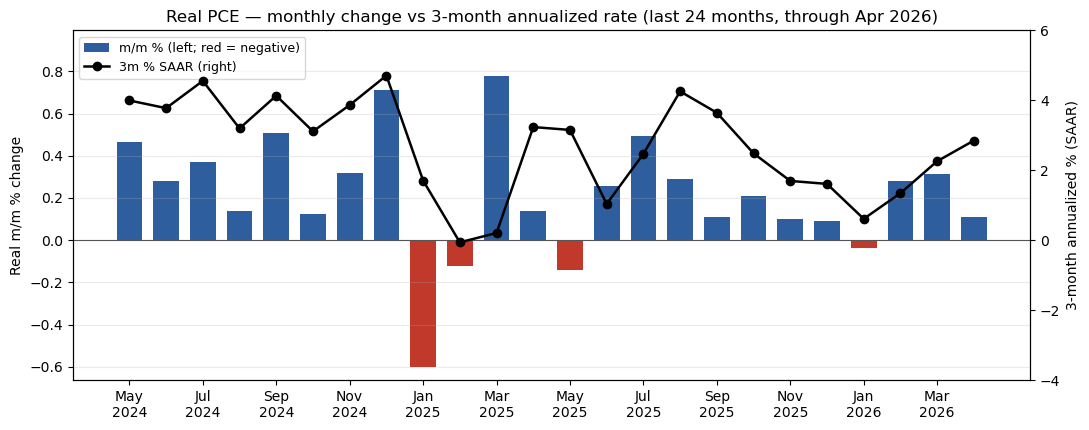

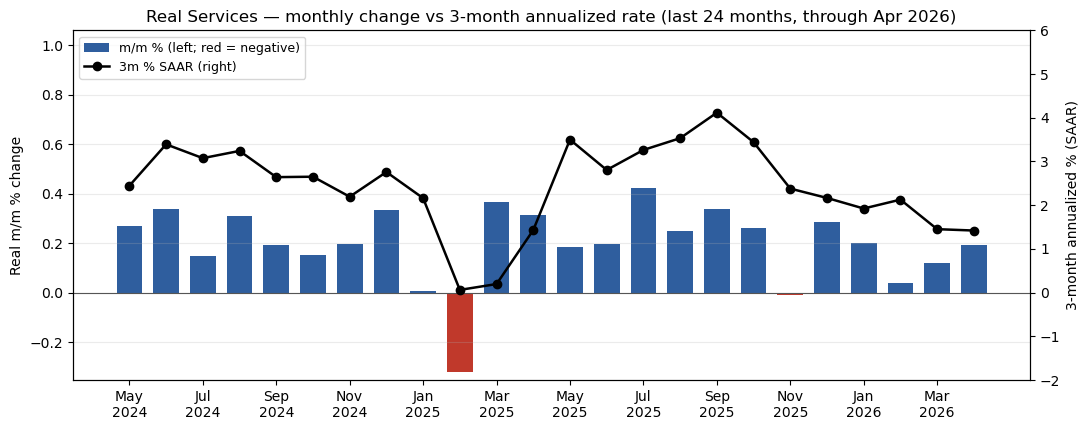

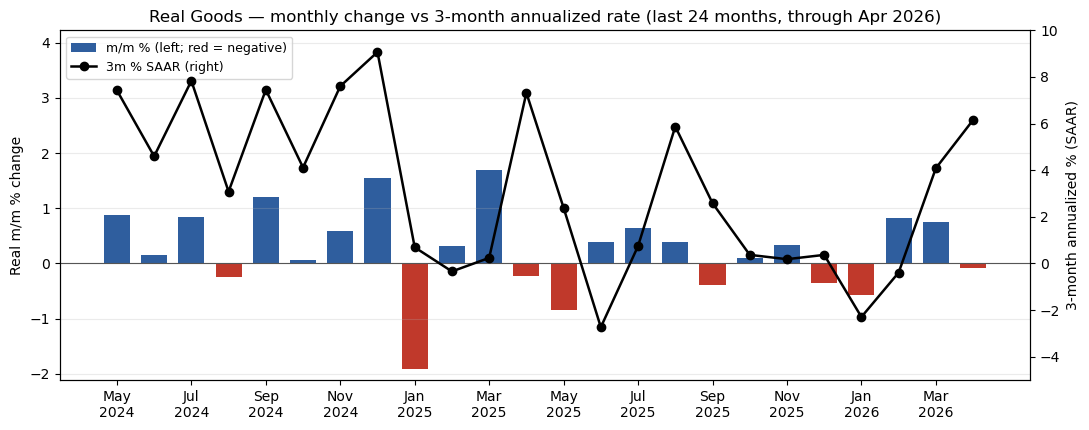

Saved momentum charts:
  C:\Users\abour\OneDrive\Economic Research\GDP\Personal Income and Spending\outputs\pce_2_8_6_momentum_total.png
  C:\Users\abour\OneDrive\Economic Research\GDP\Personal Income and Spending\outputs\pce_2_8_6_momentum_services.png
  C:\Users\abour\OneDrive\Economic Research\GDP\Personal Income and Spending\outputs\pce_2_8_6_momentum_goods.png


In [13]:
# --- 8.5 Momentum charts: m/m (bars) vs 3-month annualized rate (line, right axis) ---
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

N_DUAL_MONTHS = 24                                    # window for the momentum charts

# 3-month annualized growth (SAAR) from chained levels: (X_t / X_{t-3})**4 - 1
r3m = (rlev / rlev.shift(3)) ** 4 * 100 - 100

def momentum_chart(code, label, fname, saar_ylim, window=N_DUAL_MONTHS):
    idx = rlev.index[-window:]
    x = np.arange(len(idx))
    mm_vals  = rmm.loc[idx, code].to_numpy()          # simple m/m % (bars)
    saar_val = r3m.loc[idx, code].to_numpy()          # 3m annualized % (line)
    bar_col  = ["#2f5e9e" if v >= 0 else "#c0392b" for v in mm_vals]

    fig, ax1 = plt.subplots(figsize=(11, 4.4))
    ax1.bar(x, mm_vals, color=bar_col, width=0.7)
    ax1.axhline(0, color="#555", lw=0.8)
    ax1.set_ylabel("Real m/m % change")

    ax2 = ax1.twinx()
    ax2.plot(x, saar_val, "o-", color="black", lw=1.8)
    ax2.set_ylabel("3-month annualized % (SAAR)")
    ax2.set_ylim(*saar_ylim)                          # fixed right-axis range

    # align the left-axis zero with the right-axis zero, auto-fitting the bars
    lo2, hi2 = saar_ylim
    f = (0 - lo2) / (hi2 - lo2)                        # zero's fractional height on right axis
    P = max(0.0, float(np.nanmax(mm_vals))) * 1.10     # positive headroom
    N = max(0.0, float(-np.nanmin(mm_vals))) * 1.10    # negative headroom
    if   f <= 0: lo1, hi1 = 0.0, max(P, 1e-9)
    elif f >= 1: lo1, hi1 = -max(N, 1e-9), 0.0
    else:
        rng = max(N / f, P / (1 - f), 1e-9)
        lo1, hi1 = -f * rng, (1 - f) * rng
    ax1.set_ylim(lo1, hi1)

    step = max(1, len(idx) // 12)
    ax1.set_xticks(x[::step])
    ax1.set_xticklabels([idx[i].strftime("%b\n%Y") for i in x[::step]])
    ax1.set_title(f"Real {label} — monthly change vs 3-month annualized rate "
                  f"(last {window} months, through {idx[-1]:%b %Y})")
    ax1.legend(handles=[Patch(facecolor="#2f5e9e", label="m/m % (left; red = negative)"),
                        Line2D([0], [0], color="black", marker="o", lw=1.8,
                               label="3m % SAAR (right)")],
               loc="upper left", fontsize=9)
    ax1.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    fig.savefig(OUTDIR / fname, dpi=150, bbox_inches="tight")
    plt.show()

momentum_chart(PCE,      "PCE",      "pce_2_8_6_momentum_total.png",    saar_ylim=(-4, 6))
momentum_chart("DSERRC", "Services", "pce_2_8_6_momentum_services.png", saar_ylim=(-2, 6))
momentum_chart("DGDSRC", "Goods",    "pce_2_8_6_momentum_goods.png",    saar_ylim=(-5, 10))

print("Saved momentum charts:")
for f in ("pce_2_8_6_momentum_total.png", "pce_2_8_6_momentum_services.png",
          "pce_2_8_6_momentum_goods.png"):
    print(" ", (OUTDIR / f).resolve())

In [14]:
# --- 8.6 Export real results ---
def long_history_real():
    parts = {"real_level": rlev, "real_mm_pct": rmm, "real_yy_pct": ryy,
             "contrib_mm_pp_official": rcmm, "contrib_yy_pp_laspeyres": rcyy,
             "nominal_weight_pct_of_pce": share}
    frames = []
    for name, df in parts.items():
        f = df[SERIES].copy()
        f.index.name = "date"
        frames.append(f.reset_index().melt(id_vars="date", var_name="SeriesCode",
                                            value_name=name).set_index(["date", "SeriesCode"]))
    out = pd.concat(frames, axis=1).reset_index()
    out["LineNumber"]  = out["SeriesCode"].map(line_of)
    out["Description"] = out["SeriesCode"].map(DESC)
    cols = ["date", "LineNumber", "SeriesCode", "Description", "real_level",
            "real_mm_pct", "real_yy_pct", "contrib_mm_pp_official",
            "contrib_yy_pp_laspeyres", "nominal_weight_pct_of_pce"]
    return out.sort_values(["date", "LineNumber"]).reset_index(drop=True)[cols]

rfull = long_history_real()
rfull.to_csv(OUTDIR / "pce_2_8_6_full_history.csv", index=False)
build_rtable(rlatest).drop(columns="Level").to_csv(OUTDIR / "pce_2_8_6_latest_month_table.csv", index=False)
fig_r.savefig(OUTDIR / "pce_2_8_6_contributions_trend.png", dpi=150, bbox_inches="tight")

print("Wrote:")
for f in ("pce_2_8_6_full_history.csv", "pce_2_8_6_latest_month_table.csv",
          "pce_2_8_6_contributions_trend.png"):
    print(" ", (OUTDIR / f).resolve())

Wrote:
  C:\Users\abour\OneDrive\Economic Research\GDP\Personal Income and Spending\outputs\pce_2_8_6_full_history.csv
  C:\Users\abour\OneDrive\Economic Research\GDP\Personal Income and Spending\outputs\pce_2_8_6_latest_month_table.csv
  C:\Users\abour\OneDrive\Economic Research\GDP\Personal Income and Spending\outputs\pce_2_8_6_contributions_trend.png


### Notes — real (chained-dollar) section

- **Sources & units.** Real percent changes come from **Table 2.8.6** (chained $, SAAR). The
  **m/m contributions are BEA's official figures from Table 2.8.2** ("Contributions to Percent
  Change in Real PCE"), in percentage points — the exact Fisher decomposition, additive by
  construction (they sum to the real PCE m/m % change). Percent changes are *simple* one-month
  changes (not annualized), matching Table 2.8.1.
- **Year-over-year contributions** are *not* published monthly by BEA, so they are computed here
  with the **Laspeyres** approximation — prior-year share of *nominal* PCE (Table 2.8.5) × real
  12-month growth (Table 2.8.6) — aggregated bottom-up so children sum to parents.
- **Residual row.** For m/m it reflects only BEA rounding (official contributions are additive).
  For y/y it is the **chain (Fisher) residual** between the Laspeyres component sum and the
  official real PCE y/y % change — the inherent non-additivity of chained dollars.
- **Momentum charts (§8.5).** The 3-month annualized rate ("3m % SAAR") is $(X_t/X_{t-3})^4-1$ on
  the chained-dollar levels — the growth over the past three months expressed at an annual rate.
- **Why not just difference chained levels?** Chained dollars are not additive and Table 2.8.6 has
  no residual line, so differencing real levels would not reconcile. Table 2.8.2 solves this
  exactly for m/m.
- **Files written:** `outputs/pce_2_8_6_full_history.csv`,
  `outputs/pce_2_8_6_latest_month_table.csv`, `outputs/pce_2_8_6_contributions_trend.png`,
  and momentum charts `pce_2_8_6_momentum_total.png`, `pce_2_8_6_momentum_services.png`,
  `pce_2_8_6_momentum_goods.png`.

## Notes & caveats

- **Units / nature of the data.** Table 2.8.5 is *current-dollar* (nominal) PCE, seasonally
  adjusted at annual rates, in millions of dollars. Because it is nominal, the components sum to
  their aggregates and contributions are exactly additive (verified in §4).
- **Contributions are to *total PCE*.** Every line's contribution uses prior-period total PCE as
  the denominator, so contributions are directly comparable across the whole table and nest
  (children sum to parents; leaves sum to total PCE growth).
- **Weight** shown is the line's current-month share of total PCE; the contribution equals
  (prior-period share) × (own growth).
- **Revisions.** BEA revises monthly PCE; re-running the notebook pulls the latest vintage.
- **Out of scope (easy extensions):** contribution to *immediate parent* (re-base the denominator
  to each parent); *real / chained-dollar* contributions (non-additive — use Tables 2.8.6 / 2.8.3);
  finer item detail (Table 2.4.5U); memo lines (core PCE ex food & energy, energy, housing,
  market-based PCE — lines 25–31 of this table).